# Project 1 — Dirichlet–Neumann iteration

We solve the three subdomain Laplace problems with second-order finite differences. The main run uses $h=1/20$, $\omega=0.8$, and ten iterations.

In [ ]:
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

from solver import (
    assemble_apartment,
    dirichlet_matrix,
    neumann_matrix,
)

# Defining the constants
N = 20
H = 1 / N
OMEGA = 0.8
ITERATIONS = 10
WALL_TEMPERATURE = 15.0
HEATER_TEMPERATURE = 40.0
WINDOW_TEMPERATURE = 5.0
COMFORT_TEMPERATURE = 18.0
PLOT_MAX_TEMPERATURE = 60.0

# For plotting. Areas below 18°C are plotted in blue while those above 18°C are plotted in red
TEMPERATURE_LEVELS = np.arange(WINDOW_TEMPERATURE, PLOT_MAX_TEMPERATURE + 1)
TEMPERATURE_NORM = TwoSlopeNorm(
    vmin=WINDOW_TEMPERATURE,
    vcenter=COMFORT_TEMPERATURE,
    vmax=PLOT_MAX_TEMPERATURE,
)

# Max temperature set to 60°C for task 4
TEMPERATURE_TICKS = [5, 18, 30, 45, 60]

## Grid and ordering

Before we start, we fix some conventions here. 

We use Numpy arrays for our grid data. Array rows follow increasing $y$, columns follow increasing $x$. And when we flatten the array to solve the linear system, we use row-major ordering (C-style).

The endpoints of each interface ($\Gamma_1$ and $\Gamma_2$) are assigned to the temperature of the adjacent walls. When two exterior walls with different temperatures meet, we set the shared corner value to their average.

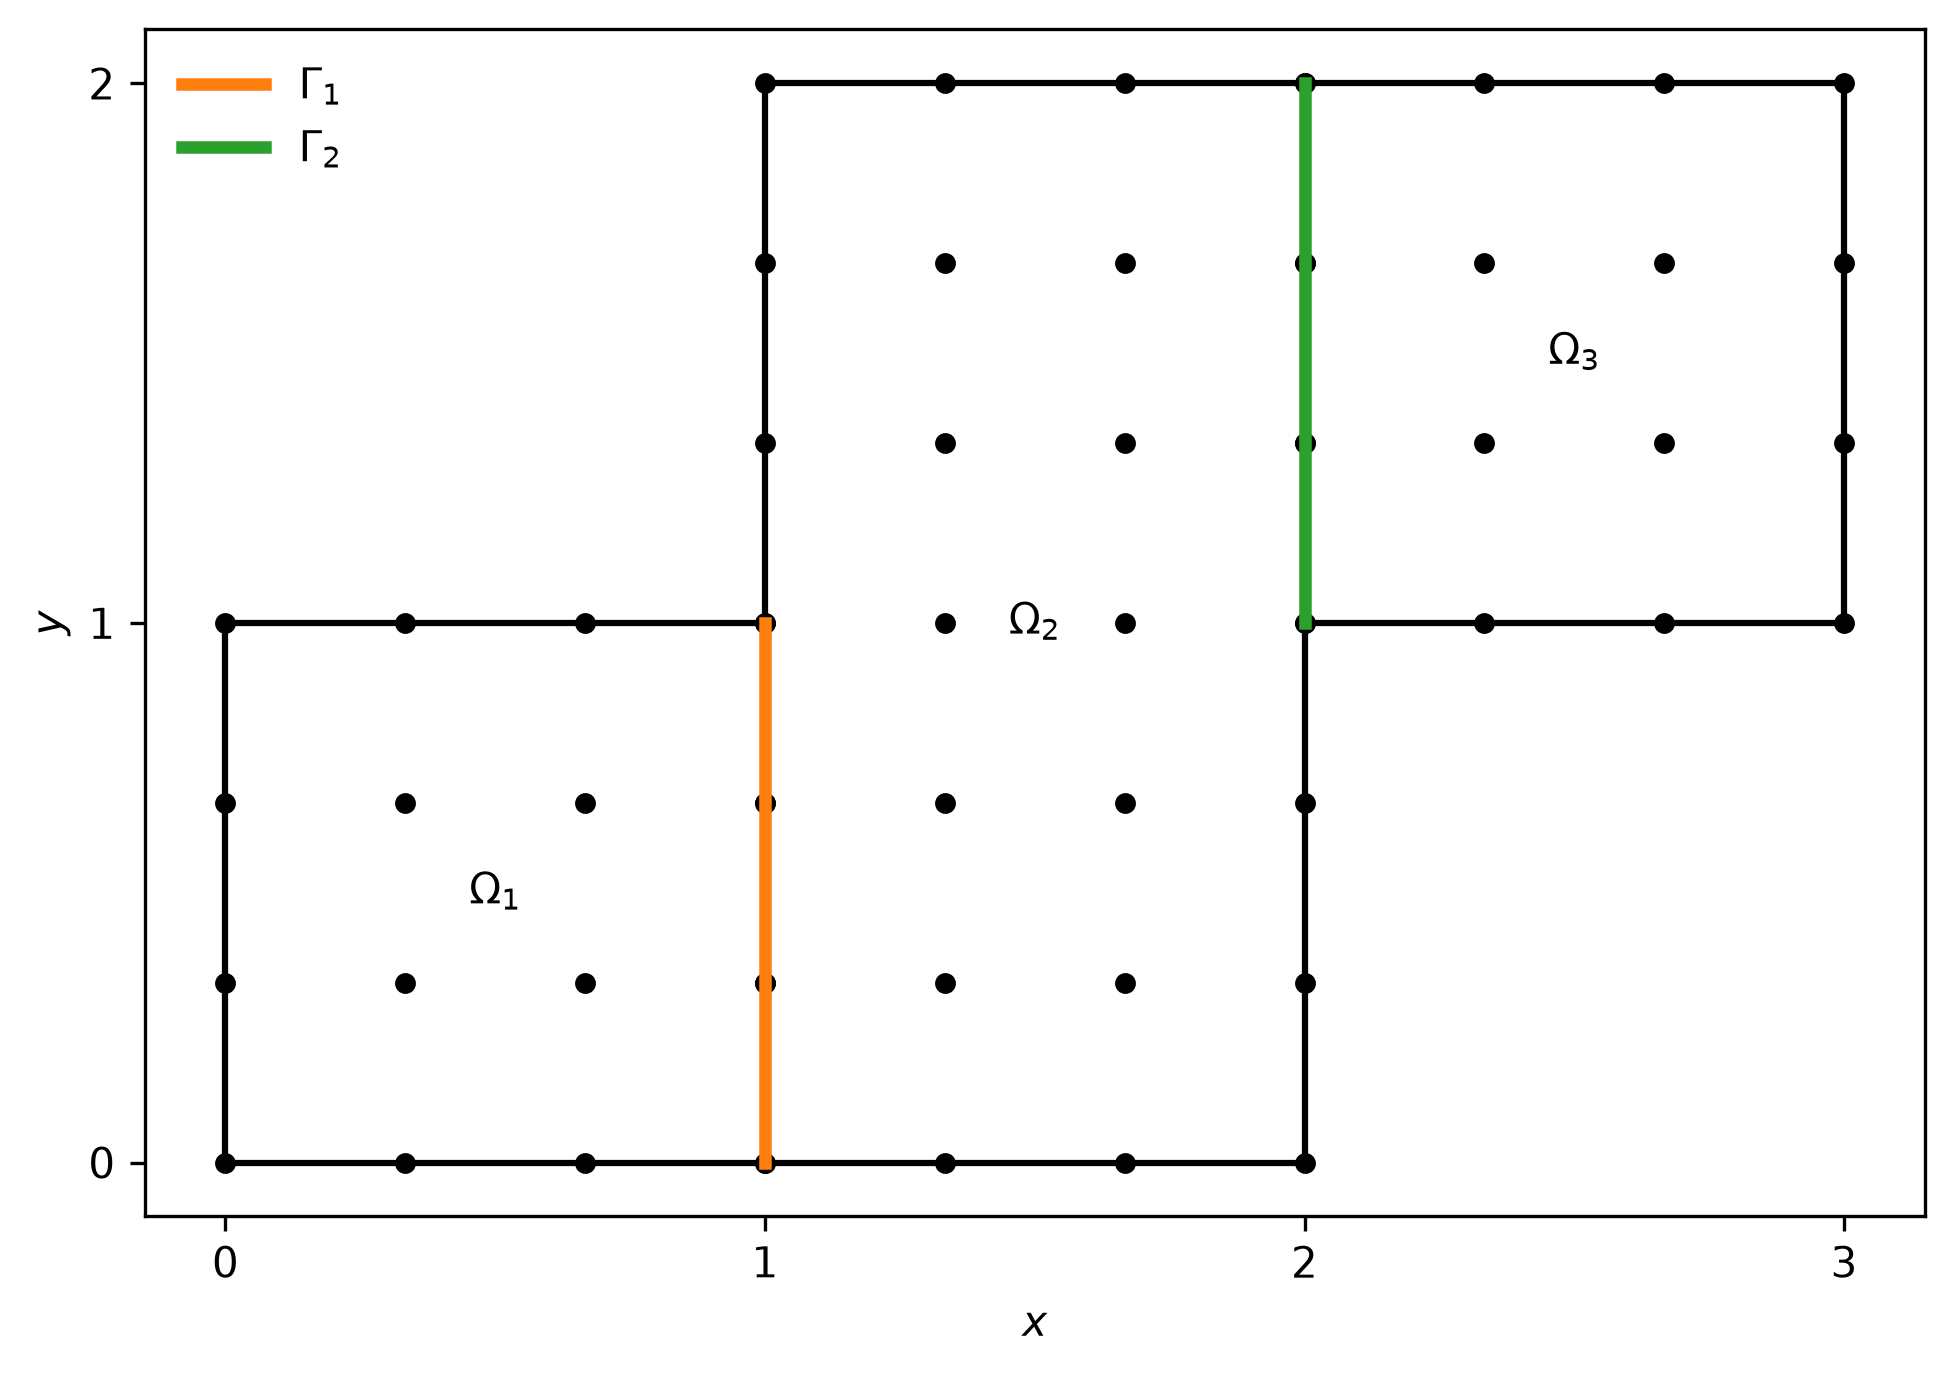

In [ ]:
h_small = 1 / 3 # For task 1 and visualization, we use a different h here
fig, ax = plt.subplots(dpi=300, layout="constrained")

# Init the room grids
rooms = [
    (0, 1, 0, 1, r"$\Omega_1$"),
    (1, 2, 0, 2, r"$\Omega_2$"),
    (2, 3, 1, 2, r"$\Omega_3$"),
]
for x0, x1, y0, y1, label in rooms:
    x = np.arange(x0, x1 + h_small / 2, h_small)
    y = np.arange(y0, y1 + h_small / 2, h_small)
    X, Y = np.meshgrid(x, y)
    ax.scatter(X, Y, s=16, color="black")
    ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], color="black")
    ax.text((x0 + x1) / 2, (y0 + y1) / 2, label, ha="center", va="center")

# Visualization the grid for task 1
ax.plot([1, 1], [0, 1], linewidth=3, color="tab:orange", label=r"$\Gamma_1$")
ax.plot([2, 2], [1, 2], linewidth=3, color="tab:green", label=r"$\Gamma_2$")
ax.set(xlabel="$x$", ylabel="$y$", xticks=np.arange(4), yticks=np.arange(3))
ax.set_aspect("equal")
ax.legend(frameon=False)
plt.show()

## Task 1 — matrices for $h=1/3$

Let $u^{(r)}_{i,j}$ denote the temperature at node $(i,j)$ in $\Omega_r$. We write $g_1^k$ and $g_2^k$ for the interface temperatures at iteration $k$, and $q_1$ and $q_3$ for the outward fluxes (the normal derivatives) used by the two outer rooms. We take the outward normal as the positive direction when evaluating the Neumann boundary condition for each outer room, so the same discrete form can be used at both interfaces.

### Boundary conditions in the three rooms

The middle room $\Omega_2$ uses Dirichlet conditions on both interfaces:
$$
u^{(2)}|_{\Gamma_1}=g_1^k,
\qquad
u^{(2)}|_{\Gamma_2}=g_2^k.
$$
Here, $g_1^k$ and $g_2^k$ come from the current solutions in $\Omega_1$ and $\Omega_3$.

The outer rooms use Neumann conditions on their interfaces:
$$
\frac{\partial u^{(1)}}{\partial \boldsymbol n_1}=q_1
\quad\text{on }\Gamma_1,
\qquad
\frac{\partial u^{(3)}}{\partial \boldsymbol n_3}=q_3
\quad\text{on }\Gamma_2.
$$
The fluxes are calculated from the new solution in $\Omega_2$. Their signs are changed when they are transferred because the outward normals of two neighbouring rooms point in opposite directions.

All exterior walls have known Dirichlet values: 15°C on normal walls, 40°C on heater walls, and 5°C on the window. We remove all fixed nodes with known dirichlet conditions from the unknown vectors and move their contributions to the right-hand side of the linear system.

### Rows of the matrices

For an interior node, multiplying the discrete Laplace equation by $-h^2$ gives
$$
4u_{i,j}-u_{i-1,j}-u_{i+1,j}-u_{i,j-1}-u_{i,j+1}=0.
$$
The corresponding matrix row has $4$ on the diagonal and $-1$ for every neighbouring unknown. If a neighbour is a Dirichlet node with value $T$, its contribution is added to the right-hand side as $+T$.

For a Neumann interface node, we use the discrete flux balance to estimate the laplacian equation. On the right edge of $\Omega_1$ it is
$$
\frac{1}{h}\left(
\frac{u^{(1)}_{N,j+1}-u^{(1)}_{N,j}}{h}
-\frac{u^{(1)}_{N,j}-u^{(1)}_{N,j-1}}{h}
+q_{1,j}
-\frac{u^{(1)}_{N,j}-u^{(1)}_{N-1,j}}{h}
\right)=0.
$$
After multiplying by $-h^2$, this becomes
$$
3u^{(1)}_{N,j}
-u^{(1)}_{N,j+1}
-u^{(1)}_{N,j-1}
-u^{(1)}_{N-1,j}
=hq_{1,j}.
$$
The left edge of $\Omega_3$ has the same form, with $u^{(3)}_{1,j}$ as the neighbour inside the room:
$$
3u^{(3)}_{0,j}
-u^{(3)}_{0,j+1}
-u^{(3)}_{0,j-1}
-u^{(3)}_{1,j}
=hq_{3,j}.
$$
These flux-balance equations replace the Laplace rows at the Neumann interface nodes.

As we mentioned in the previous part, we use row-major ordering to arrange the unknowns in the linear system. For $\Omega_1$ and $\Omega_3$,
$$
v_1=(u^{(1)}_{1,1},u^{(1)}_{2,1},u^{(1)}_{3,1},
     u^{(1)}_{1,2},u^{(1)}_{2,2},u^{(1)}_{3,2})^T,
$$
$$
v_3=(u^{(3)}_{0,1},u^{(3)}_{1,1},u^{(3)}_{2,1},
     u^{(3)}_{0,2},u^{(3)}_{1,2},u^{(3)}_{2,2})^T.
$$
For $\Omega_2$,
$$
v_2=(u^{(2)}_{1,1},u^{(2)}_{2,1},
     u^{(2)}_{1,2},u^{(2)}_{2,2},\ldots,
     u^{(2)}_{1,5},u^{(2)}_{2,5})^T.
$$

Thus, in each room $\Omega_r$, we have a linear system of the form
$$
A_r v_r = b_r,
$$

where $A_r$ represents the discrete Laplace operator with the appropriate boundary conditions, $v_r$ is the vector of unknown temperatures, and $b_r$ is the right-hand side vector that includes contributions from Dirichlet boundary conditions and Neumann conditions. 

Detailed implementation of the construction of our linear systems and the solver itself can be found in [solver.py](solver.py).

In [3]:
# Construct A2 with Dirichlet conditions
A2_small = dirichlet_matrix(3, 6)

# Construct A1 and A3 with Neumann conditions
A1_small = neumann_matrix(3, "right")
A3_small = neumann_matrix(3, "left")


np.set_printoptions(linewidth=120, suppress=True)
print("A1 =")
print(A1_small)
print("\nA2 =")
print(A2_small)
print("\nA3 =")
print(A3_small)

A1 =
[[ 4. -1.  0. -1.  0.  0.]
 [-1.  4. -1.  0. -1.  0.]
 [ 0. -1.  3.  0.  0. -1.]
 [-1.  0.  0.  4. -1.  0.]
 [ 0. -1.  0. -1.  4. -1.]
 [ 0.  0. -1.  0. -1.  3.]]

A2 =
[[ 4. -1. -1.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  4.  0. -1.  0.  0.  0.  0.  0.  0.]
 [-1.  0.  4. -1. -1.  0.  0.  0.  0.  0.]
 [ 0. -1. -1.  4.  0. -1.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  4. -1. -1.  0.  0.  0.]
 [ 0.  0.  0. -1. -1.  4.  0. -1.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  4. -1. -1.  0.]
 [ 0.  0.  0.  0.  0. -1. -1.  4.  0. -1.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.  4. -1.]
 [ 0.  0.  0.  0.  0.  0.  0. -1. -1.  4.]]

A3 =
[[ 3. -1.  0. -1.  0.  0.]
 [-1.  4. -1.  0. -1.  0.]
 [ 0. -1.  4.  0.  0. -1.]
 [-1.  0.  0.  3. -1.  0.]
 [ 0. -1.  0. -1.  4. -1.]
 [ 0.  0. -1.  0. -1.  4.]]


## Dirichlet–Neumann iteration

Since the Jupyter kernel runs as a single MPI process, we put the 3-rank MPI code in a separate file [mpi_driver.py](mpi_driver.py), and call it with `mpiexec` from the notebook. The file contains the three-rank communication and iteration. The notebook and MPI driver use the same solver functions.

The full grids start at 15°C, after which the heater, window, and exterior wall values are imposed. Thus the initial Dirichlet trace on both artificial interfaces is also 15°C. Rank 0 solves $\Omega_2$; ranks 1 and 2 solve $\Omega_1$ and $\Omega_3$.

In [4]:
def run_case(
    output,
    n=N,
    omega=OMEGA,
    iterations=ITERATIONS,
    wall=WALL_TEMPERATURE,
    heater=HEATER_TEMPERATURE,
    window=WINDOW_TEMPERATURE,
):
    command = [
        "mpiexec", "-n", "3", sys.executable, "mpi_driver.py",
        "--n", str(n),
        "--omega", str(omega),
        "--iterations", str(iterations),
        "--wall", str(wall),
        "--heater", str(heater),
        "--window", str(window),
        "--output", output,
    ]
    run = subprocess.run(command, capture_output=True, text=True, check=True)
    print(run.stdout.strip())
    return np.load(output)


data = run_case("temperature_data.npz")

Saved temperature_data.npz after 10 iterations


## Task 2 — is the heating adequate?

The assignment handout gives no threshold for "adequate" heating. We use 18°C as a stated working threshold and inspect only interior apartment nodes. We say that the heating is adequate if the minimum temperature is at least 18°C.

The minimum, mean, and fraction below 18°C summarize the result.

In [5]:
def get_interior_values(u1, u2, u3):
    apartment = assemble_apartment(u1, u2, u3)
    present = np.isfinite(apartment)
    interior = present.copy()
    interior[[0, -1], :] = False
    interior[:, [0, -1]] = False
    interior &= (
        np.roll(present, 1, axis=0)
        & np.roll(present, -1, axis=0)
        & np.roll(present, 1, axis=1)
        & np.roll(present, -1, axis=1)
    )
    return apartment, apartment[interior]


u1, u2, u3 = data["u1"], data["u2"], data["u3"]
apartment, interior_values = get_interior_values(u1, u2, u3)

minimum = interior_values.min()
mean = interior_values.mean()
below_18 = np.mean(interior_values < 18.0)

print(f"Interior minimum: {minimum:.2f} °C")
print(f"Interior mean: {mean:.2f} °C")
print(f"Interior nodes below 18 °C: {below_18:.1%}")
print(f"Last interface update: {data['history'][-1]:.3f} °C")

Interior minimum: 5.96 °C
Interior mean: 19.89 °C
Interior nodes below 18 °C: 46.4%
Last interface update: 0.012 °C


The heating is not adequate under this criterion. Although the mean is close to 20°C, a substantial part of the apartment remains below 18°C, especially near the large window as shown in the temperature distribution in task 3 (so you better close it :/).

## Task 3 — temperature distribution

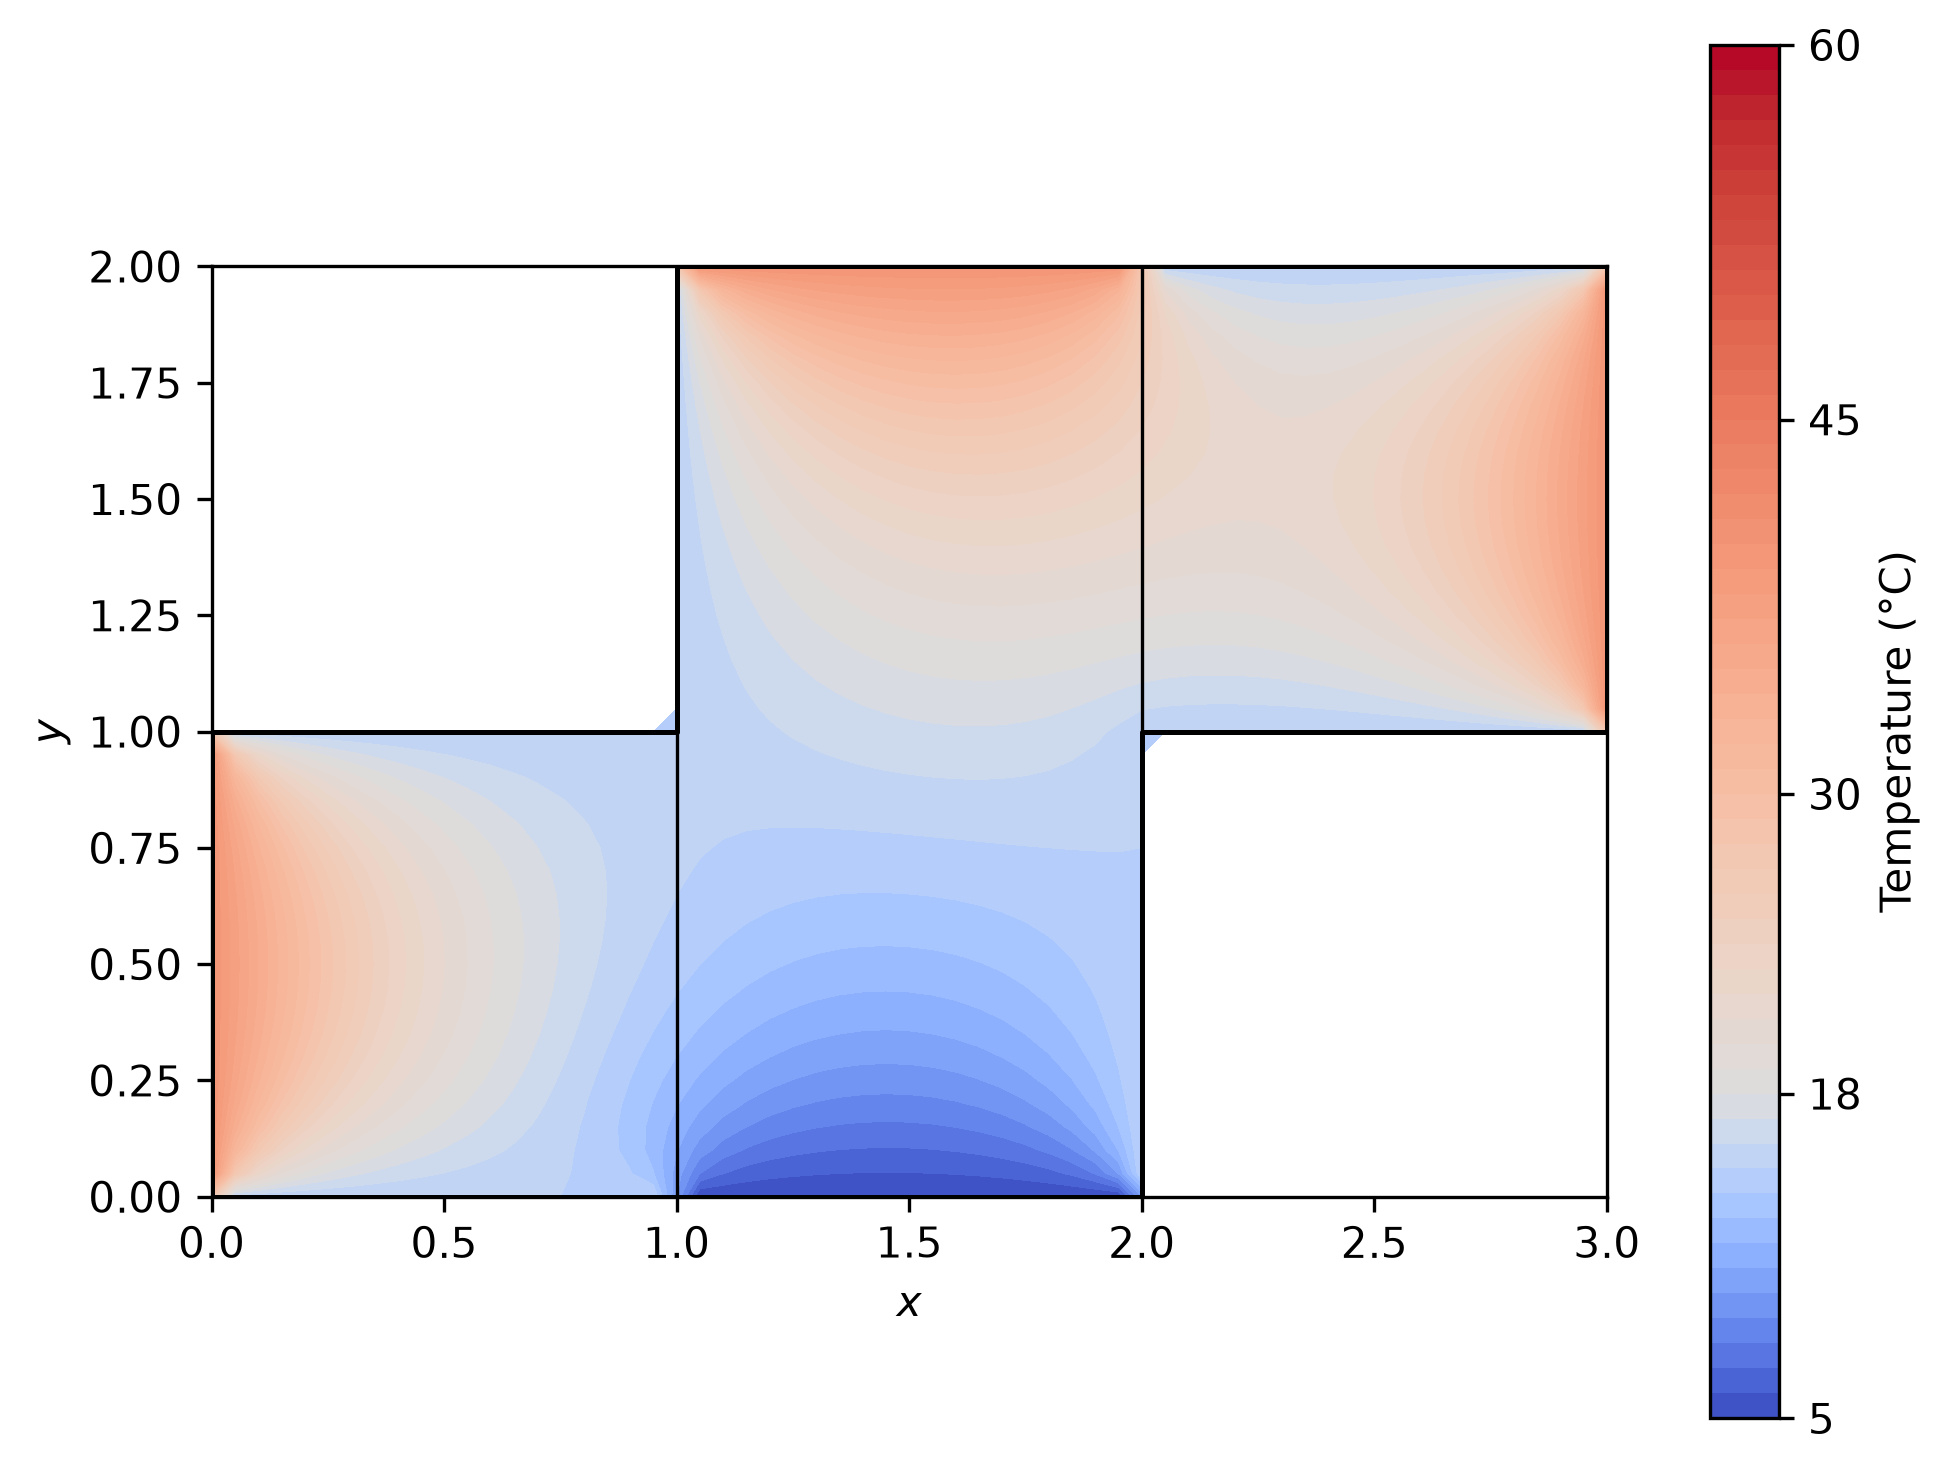

In [6]:
x = np.arange(apartment.shape[1]) * H
y = np.arange(apartment.shape[0]) * H
masked_temperature = np.ma.masked_invalid(apartment)

fig, ax = plt.subplots(dpi=300, layout="constrained")
contour = ax.contourf(
    x,
    y,
    masked_temperature,
    levels=TEMPERATURE_LEVELS,
    cmap="coolwarm",
    norm=TEMPERATURE_NORM,
)
ax.plot([0, 2, 2, 3, 3, 1, 1, 0, 0],
        [0, 0, 1, 1, 2, 2, 1, 1, 0], color="black", linewidth=1.2)
ax.plot([1, 1], [0, 1], color="black", linewidth=0.8)
ax.plot([2, 2], [1, 2], color="black", linewidth=0.8)
ax.set(xlabel="$x$", ylabel="$y$", aspect="equal")
fig.colorbar(
    contour,
    ax=ax,
    ticks=TEMPERATURE_TICKS,
    label="Temperature (°C)",
)
plt.show()

The coldest region is concentrated around the window at the bottom of $\Omega_2$. The three heaters raise the nearby temperatures, but their effect is not enough to keep the whole interior above 18°C after the prescribed ten iterations.

## Convergence check

We further check the convergence of the Dirichlet–Neumann iteration by plotting the maximum difference in interface temperatures at each iteration. The plot shows that the interface temperatures converge well after a few iterations, which means our Dirichlet–Neumann iteration is working as expected.

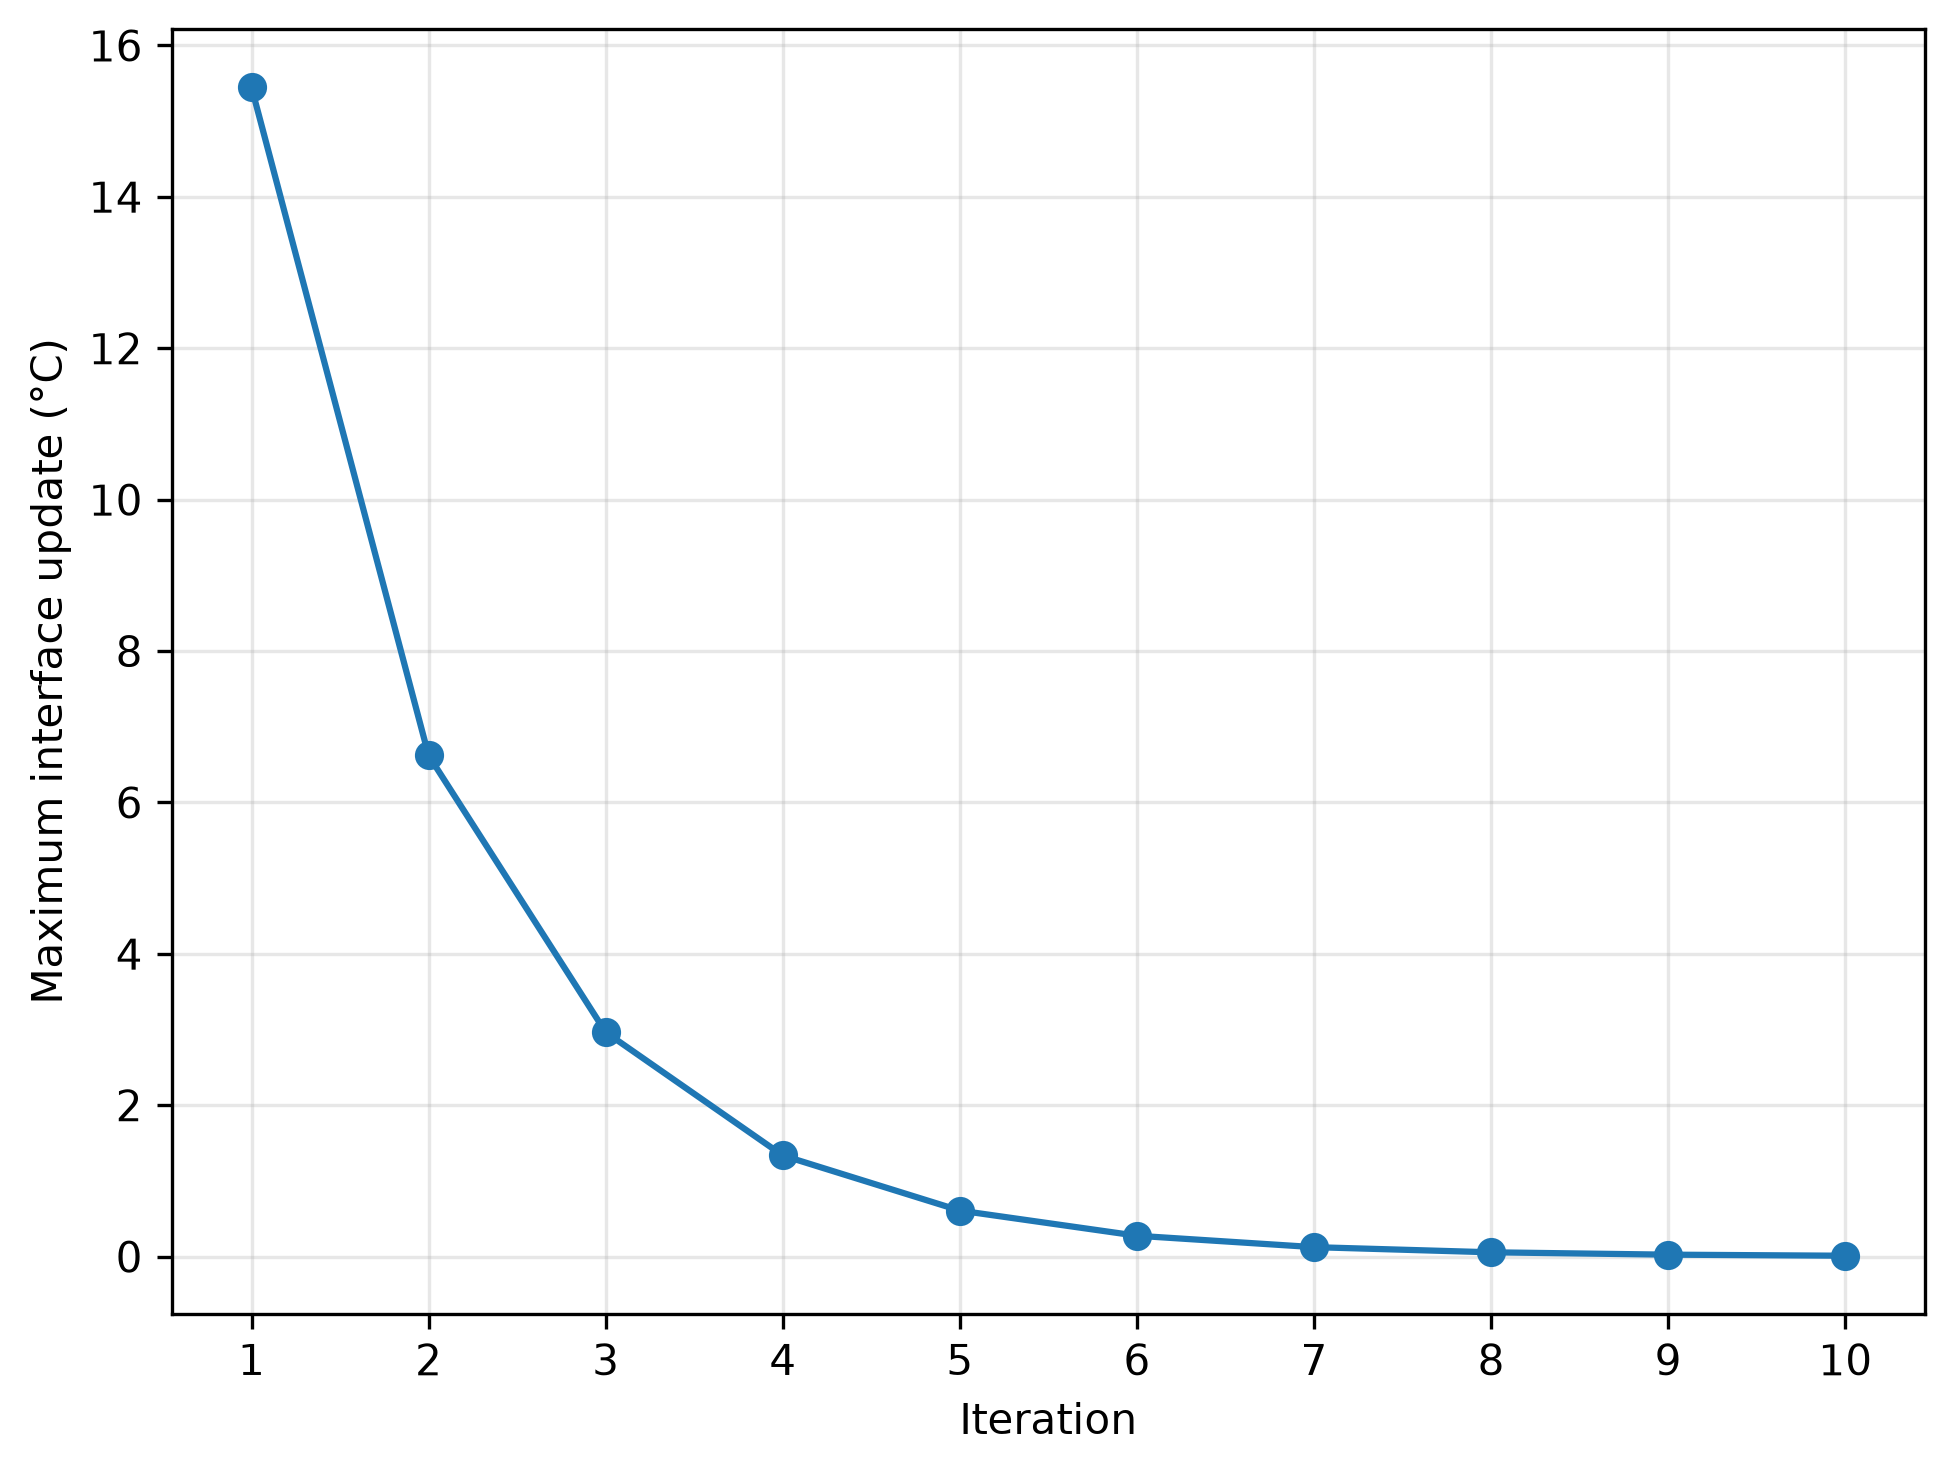

In [7]:
fig, ax = plt.subplots(dpi=300, layout="constrained")
iteration_numbers = np.arange(1, ITERATIONS + 1)
ax.plot(iteration_numbers, data["history"], marker="o")
ax.set(xlabel="Iteration", ylabel="Maximum interface update (°C)", xticks=iteration_numbers)
ax.grid(True, which="both", alpha=0.3)
plt.show()

## Task 4 — varying the heater temperature

We keep $h=1/20$, $\omega=0.8$, and compare heater temperatures of 40°C, 50°C, and 60°C. The iteration count is set to 20 to ensure convergence.

In [8]:
heater_cases = {}

for heater_temperature in (40.0, 50.0, 60.0):
    output = f"task4_heater_{int(heater_temperature)}.npz"
    heater_cases[heater_temperature] = run_case(output, heater=heater_temperature, iterations=20)

print(f"{'Heater':>8} {'Minimum':>10} {'Mean':>10} {'Below 18°C':>12}")
for heater_temperature, case in heater_cases.items():
    _, values = get_interior_values(case["u1"], case["u2"], case["u3"])
    print(
        f"{heater_temperature:7.0f}°C "
        f"{values.min():9.2f}°C "
        f"{values.mean():9.2f}°C "
        f"{np.mean(values < 18.0):11.1%}"
    )

Saved task4_heater_40.npz after 20 iterations
Saved task4_heater_50.npz after 20 iterations
Saved task4_heater_60.npz after 20 iterations
  Heater    Minimum       Mean   Below 18°C
     40°C      5.96°C     19.89°C       46.4%
     50°C      6.00°C     22.26°C       40.1%
     60°C      6.04°C     24.63°C       35.5%


Increasing the heater temperature raises the mean interior temperature and reduces the fraction of nodes below 18°C. However, the minimum changes very little because the coldest nodes remain close to the 5°C window.

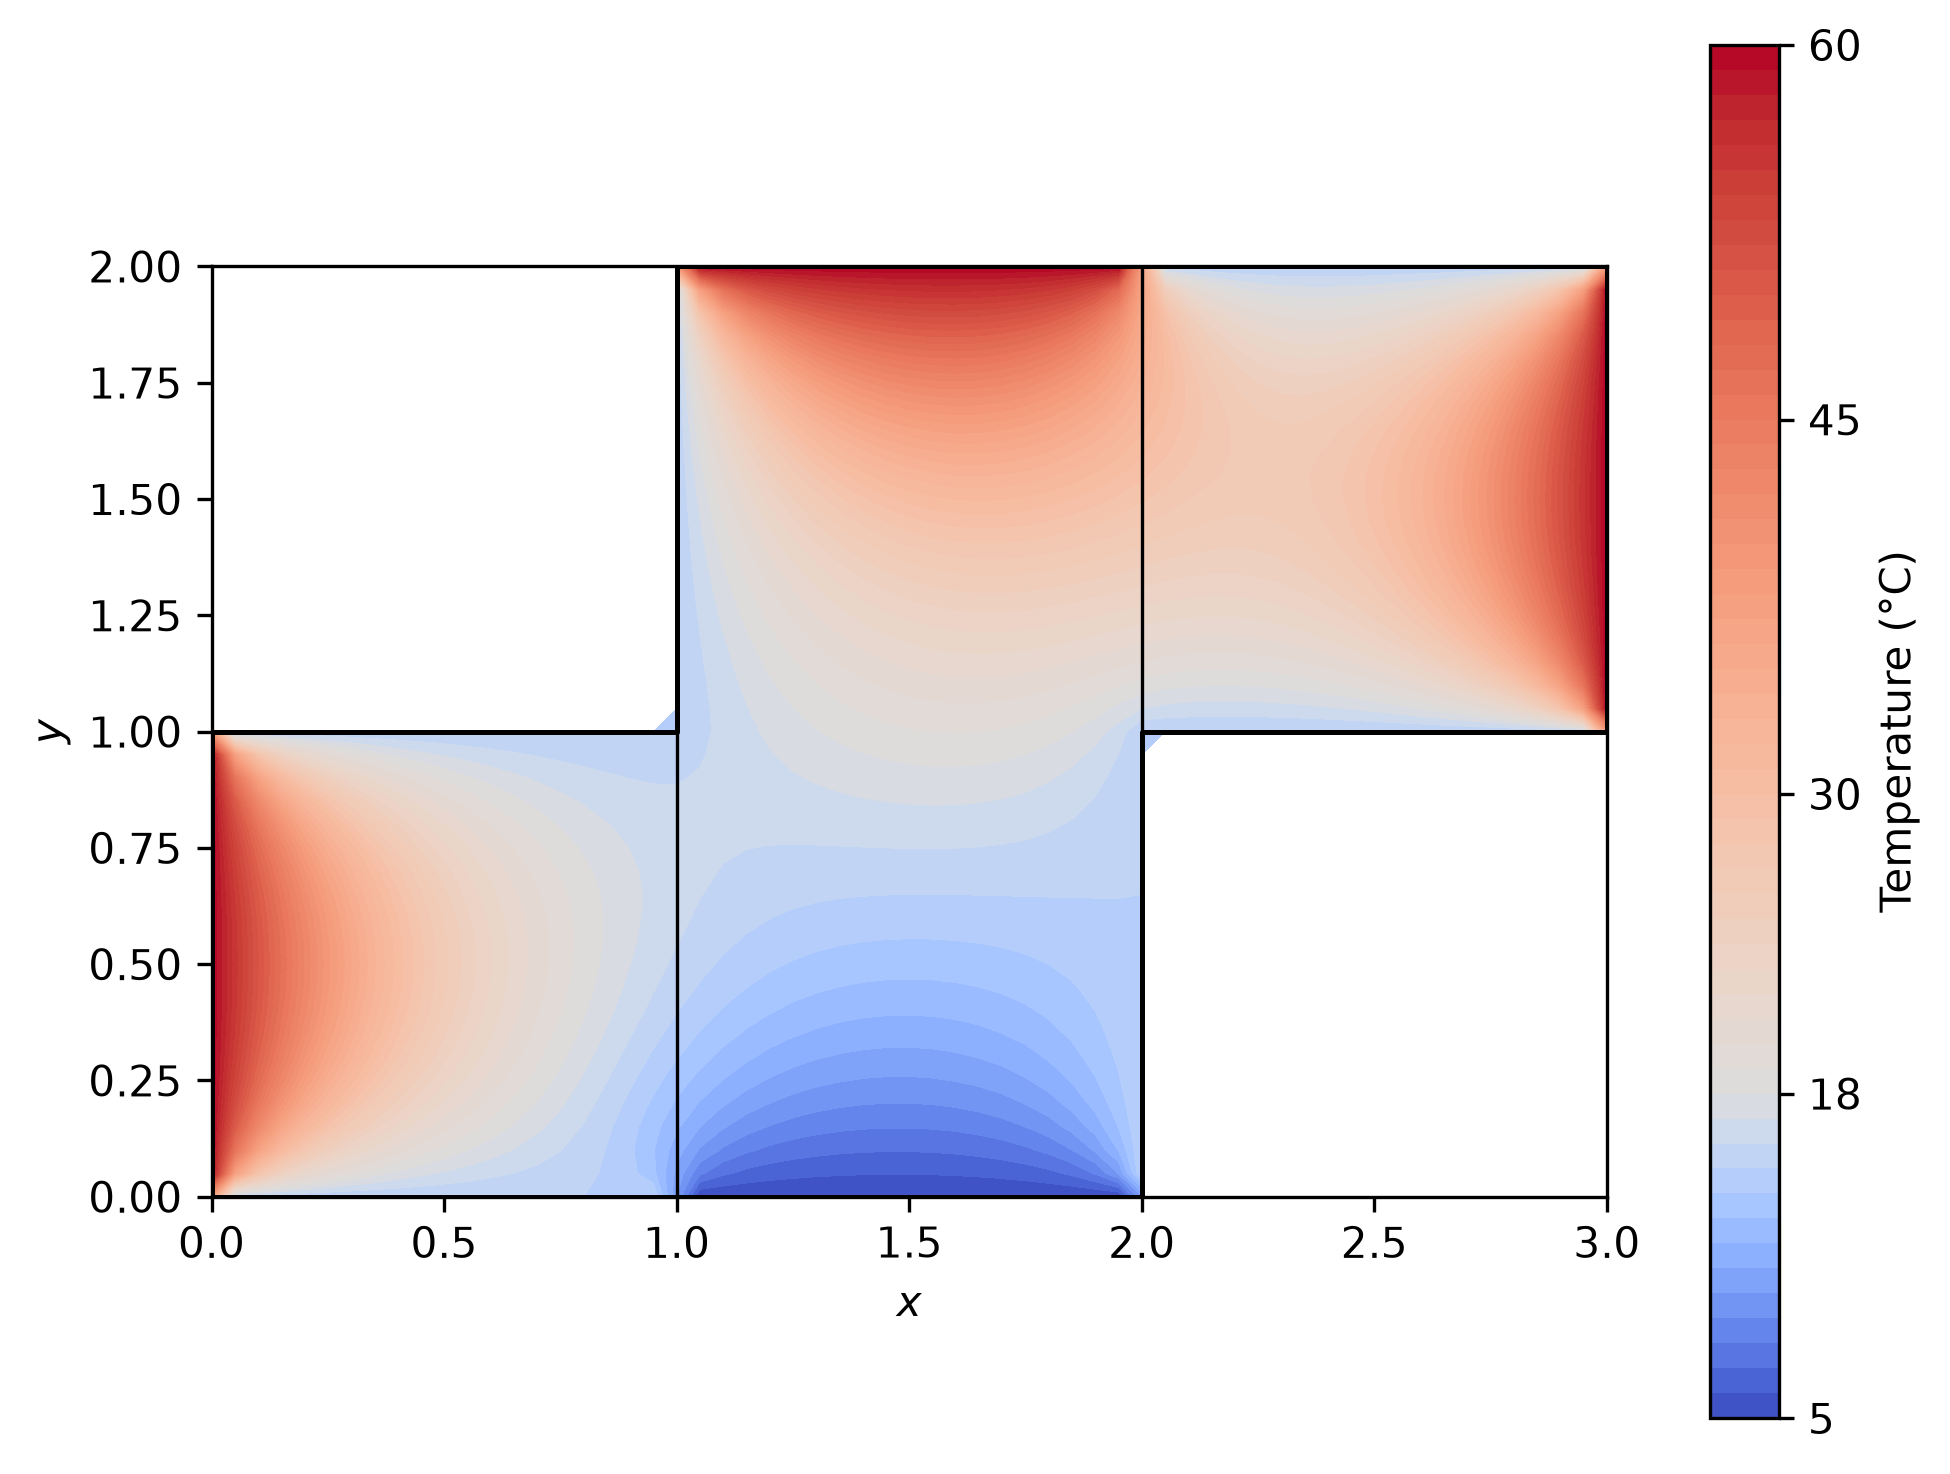

In [9]:
# Visualize the 60°C heater case

data = heater_cases[60.0]
u1, u2, u3 = data["u1"], data["u2"], data["u3"]
apartment, interior_values = get_interior_values(u1, u2, u3)

x = np.arange(apartment.shape[1]) * H
y = np.arange(apartment.shape[0]) * H
masked_temperature = np.ma.masked_invalid(apartment)

fig, ax = plt.subplots(dpi=300, layout="constrained")
contour = ax.contourf(
    x,
    y,
    masked_temperature,
    levels=TEMPERATURE_LEVELS,
    cmap="coolwarm",
    norm=TEMPERATURE_NORM,
)
ax.plot([0, 2, 2, 3, 3, 1, 1, 0, 0],
        [0, 0, 1, 1, 2, 2, 1, 1, 0], color="black", linewidth=1.2)
ax.plot([1, 1], [0, 1], color="black", linewidth=0.8)
ax.plot([2, 2], [1, 2], color="black", linewidth=0.8)
ax.set(xlabel="$x$", ylabel="$y$", aspect="equal")
fig.colorbar(
    contour,
    ax=ax,
    ticks=TEMPERATURE_TICKS,
    label="Temperature (°C)",
)
plt.show()